In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.load_data import load_processed_original_data, resample_data  # noqa: E402
from utils.constants import FIGURES_DIR  # noqa: E402
from utils.configure_scienceplots import configure_scienceplots  # noqa: E402

FIGSIZE = (8, 4)

HISTPLOT_FIGURES_DIR = FIGURES_DIR / "histplots"
HISTPLOT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

HEATMAP_FIGURES_DIR = FIGURES_DIR / "heatmaps"
HEATMAP_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
configure_scienceplots()

In [4]:
original_df = load_processed_original_data(parse_dates=True)
original_df.head()

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792


## Heatmap related to multiple columns

In [5]:
df = original_df.copy()

GRAVEDAD = {"SOLO DANOS": 0, "CON HERIDOS": 1, "CON MUERTOS": 2}
df["GRAVEDAD"] = df["GRAVEDAD"].map(GRAVEDAD)

CLASE = {
    "ATROPELLO": 0,
    "CHOQUE": 1,
    "VOLCAMIENTO": 2,
    "CAIDA DE OCUPANTE": 3,
    "AUTOLESION": 4,
    "INCENDIO": 5,
    "OTRO": 6,
}
df["CLASE"] = df["CLASE"].map(CLASE)

LOCALIDAD = {
    "TEUSAQUILLO": 0,
    "ENGATIVA": 1,
    "PUENTE ARANDA": 2,
    "RAFAEL URIBE URIBE": 3,
    "SUBA": 4,
    "LOS MARTIRES": 5,
    "FONTIBON": 6,
    "USME": 7,
    "CIUDAD BOLIVAR": 8,
    "KENNEDY": 9,
    "TUNJUELITO": 10,
    "ANTONIO NARIÑO": 11,
    "BOSA": 12,
    "CHAPINERO": 13,
    "BARRIOS UNIDOS": 14,
    "USAQUEN": 15,
    "SANTA FE": 16,
    "CANDELARIA": 17,
    "SAN CRISTOBAL": 18,
}
df["LOCALIDAD"] = df["LOCALIDAD"].map(LOCALIDAD)

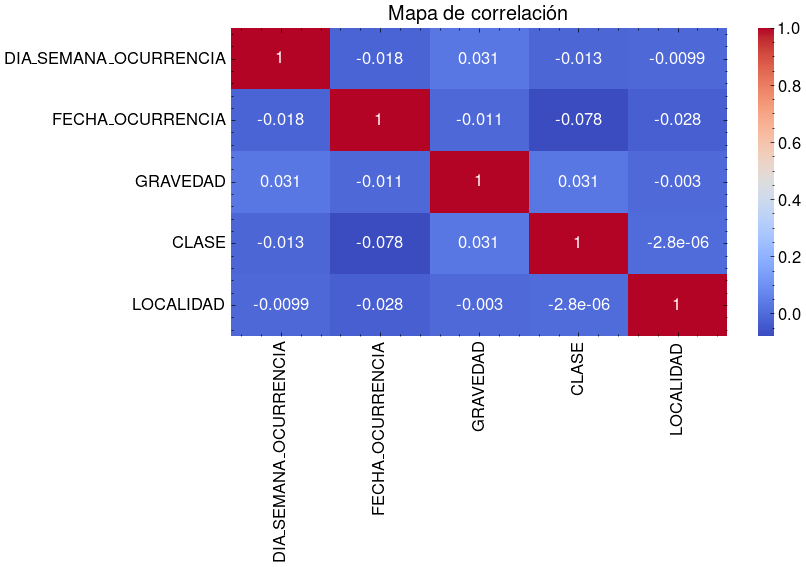

In [6]:
corr = df[["DIA_SEMANA_OCURRENCIA", "FECHA_OCURRENCIA", "GRAVEDAD", "CLASE", "LOCALIDAD"]].corr()

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.heatmap(corr, annot=True, cmap="coolwarm")

ax.set_title("Mapa de correlación")
fig.savefig(HEATMAP_FIGURES_DIR / "correlation_map.pdf")

plt.show()

## Heatmap related to GRAVEDAD and CLASE

In [20]:
df = resample_data(freq="1W", multi_index=True)

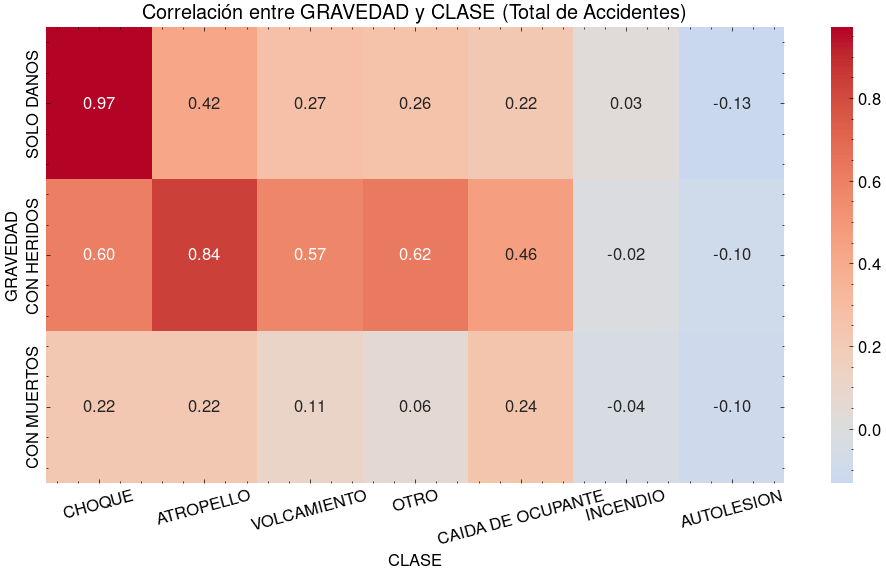

In [45]:
# Extract columns from GRAVEDAD and CLASE
gravedad_cols = list(df["GRAVEDAD"].columns)
clase_cols = list(df["CLASE"].columns)

# Create a matrix for the heatmap
# Sum all values over time
gravedad_data = df["GRAVEDAD"][gravedad_cols].sum()
clase_data = df["CLASE"][clase_cols].sum()

# Calculate correlation between each GRAVEDAD and CLASE
heatmap_data = []
for gravedad in gravedad_cols:
    row = []
    for clase in clase_cols:
        valor = df["GRAVEDAD"][gravedad].corr(df["CLASE"][clase])
        row.append(valor)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=gravedad_cols, columns=clase_cols)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)

ax.set_title("Correlación entre GRAVEDAD y CLASE (Total de Accidentes)")
ax.set_xlabel("CLASE")
ax.set_ylabel("GRAVEDAD")

plt.xticks(rotation=15)

fig.tight_layout()

fig.savefig(HEATMAP_FIGURES_DIR / "gravedad_clase_correlation.pdf")
plt.show()

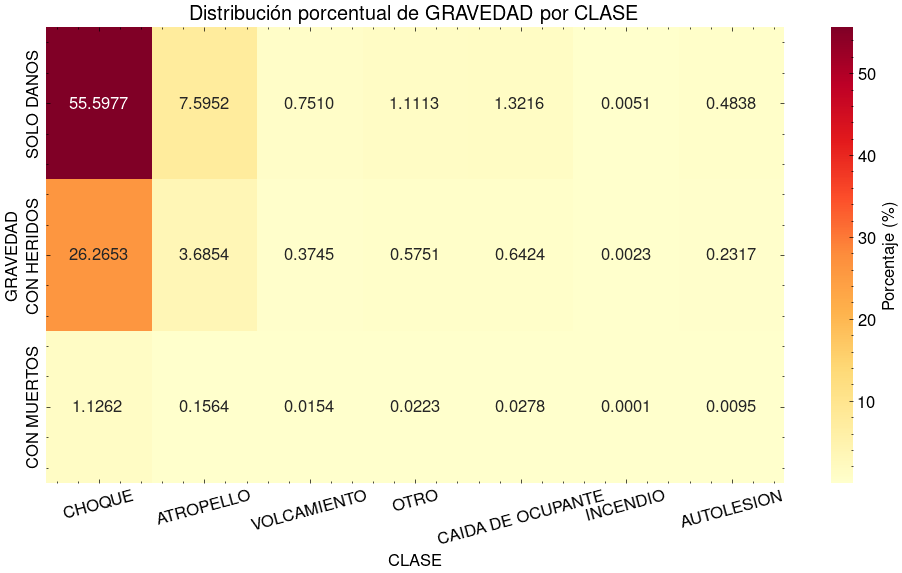

In [51]:
# Interaction matrix between GRAVEDAD and CLASE
heatmap_data = []
for gravedad in gravedad_cols:
    row = []
    for clase in clase_cols:
        value = (df["GRAVEDAD"][gravedad] * df["CLASE"][clase]).sum()
        row.append(value)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=gravedad_cols, columns=clase_cols)

# Normalize to get percentages
heatmap_pct = (heatmap_df / heatmap_df.sum().sum()) * 100

# Plot the heatmap
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": r"Porcentaje (\%)"},
)
ax.set_title("Distribución porcentual de GRAVEDAD por CLASE")
ax.set_xlabel("CLASE")
ax.set_ylabel("GRAVEDAD")
plt.xticks(rotation=15)

fig.tight_layout()
fig.savefig(HEATMAP_FIGURES_DIR / "gravedad_clase_percentage.pdf")
plt.show()